## STAGE 2 - DATA CLEANING

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from urllib.parse import quote_plus

In [76]:
# Load the original dataset
edtech = pd.read_csv(
    r"edtech_student_activity_realted_dataset_Manidheer_vamsi 1 (3).csv"
)

In [77]:
location = edtech["location"].value_counts()

print(location)

location
New Robert            19
East John             19
East James            18
West Michael          18
South Michael         18
                      ..
Port Markshire&        1
Simmonshaven?          1
North Michaelbury$     1
Davisborough*          1
Jenniferstad$          1
Name: count, Length: 12604, dtype: int64


In [78]:
# Display the number of rows and columns
print("Initial Dataset Shape:", edtech.shape)

Initial Dataset Shape: (22400, 20)


In [79]:
# Display the first 5 records
edtech.head()

,student_id,course_id,login_frequency,time_spent_hours,videos_watched,quizzes_attempted,assignments_submitted,forum_posts,last_login_date,device_type,location,engagement_score,dropout_risk_score,subscription_type,payment_status,referral_source,avg_session_time,inactive_days,completion_flag,satisfaction_rating
0,0.0,202.0,45.0,46.0,123.0,29.0,11.0,NaN,2025-12-23,Tablet,North Matthewbury,59.068571,61.815459,Premium,Paid,Social,69.497195,10.0,0.0,4.713971
1,1.0,448.0,49.0,NaN,104.0,5.0,17.0,NaN,2026-07-01,Tablet,North Reneeburgh,9.223219,99.508408,Premium,Pending,Organic,19.806986,57.0,1.0,2.276632
2,2.0,370.0,6.0,327.0,NaN,1.0,5.0,22.0,NaN,Tablet,West Robertville,85.645141,31.897529,Free,Paid,Ads,63.531993,6.0,1.0,3.613497
3,3.0,206.0,NaN,44.0,188.0,14.0,8.0,16.0,2025-09-24,Laptop,North Kennethmouth,65.626710,37.833001,Free,Paid,Ads,44.112624,51.0,0.0,4.759466
4,4.0,171.0,7.0,320.0,14.0,33.0,8.0,26.0,2025-09-27,Tablet,East Valeriestad,52.192341,87.033665,Premium,Pending,Organic,103.788271,50.0,0.0,2.804617


In [80]:
# Display all column names
print("Column Names:")
print(edtech.columns.tolist())

Column Names:
['student_id', 'course_id', 'login_frequency', 'time_spent_hours', 'videos_watched', 'quizzes_attempted', 'assignments_submitted', 'forum_posts', 'last_login_date', 'device_type', 'location', 'engagement_score', 'dropout_risk_score', 'subscription_type', 'payment_status', 'referral_source', 'avg_session_time', 'inactive_days', 'completion_flag', 'satisfaction_rating']


In [81]:
# Display data types of all columns
print("\nData Types:")
print(edtech.dtypes)


Data Types:
student_id               float64
course_id                float64
login_frequency          float64
time_spent_hours         float64
videos_watched           float64
quizzes_attempted        float64
assignments_submitted    float64
forum_posts              float64
last_login_date              str
device_type                  str
location                     str
engagement_score         float64
dropout_risk_score       float64
subscription_type            str
payment_status               str
referral_source              str
avg_session_time         float64
inactive_days            float64
completion_flag          float64
satisfaction_rating      float64
dtype: object


In [82]:
# Display basic information about the dataset
print("\nDataset Information:")
edtech.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 22400 entries, 0 to 22399
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20821 non-null  float64
 1   course_id              20823 non-null  float64
 2   login_frequency        20828 non-null  float64
 3   time_spent_hours       20842 non-null  float64
 4   videos_watched         20812 non-null  float64
 5   quizzes_attempted      20817 non-null  float64
 6   assignments_submitted  20836 non-null  float64
 7   forum_posts            20842 non-null  float64
 8   last_login_date        20824 non-null  str    
 9   device_type            20834 non-null  str    
 10  location               20836 non-null  str    
 11  engagement_score       20831 non-null  float64
 12  dropout_risk_score     20834 non-null  float64
 13  subscription_type      20846 non-null  str    
 14  payment_status         20832 non-null  str 

In [83]:
# Count missing values in every column
missing_values = edtech.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values[missing_values > 0])

Missing Values in Each Column:
student_id               1579
course_id                1577
login_frequency          1572
time_spent_hours         1558
videos_watched           1588
quizzes_attempted        1583
assignments_submitted    1564
forum_posts              1558
last_login_date          1576
device_type              1566
location                 1564
engagement_score         1569
dropout_risk_score       1566
subscription_type        1554
payment_status           1568
referral_source          1561
avg_session_time         1580
inactive_days            1566
completion_flag          1568
satisfaction_rating      1579
dtype: int64


In [84]:
# List of numerical columns
numeric_columns = [
    "login_frequency",
    "time_spent_hours",
    "videos_watched",
    "quizzes_attempted",
    "assignments_submitted",
    "forum_posts",
    "engagement_score",
    "dropout_risk_score",
    "avg_session_time",
    "inactive_days",
    "satisfaction_rating"
]

# Fill missing values with the median
# Then round the values and convert them to integers
for col in numeric_columns:
    
    # Fill missing values using median
    edtech[col] = edtech[col].fillna(edtech[col].median())
    
    # Round decimal values and convert to integer
    edtech[col] = edtech[col].round().astype("int64")

print("Missing numerical values handled successfully.")

Missing numerical values handled successfully.


In [85]:
# Verify that numerical columns no longer contain missing values
print("Missing values in numerical columns:")

for col in numeric_columns:
    print(f"{col}: {edtech[col].isnull().sum()}")

Missing values in numerical columns:
login_frequency: 0
time_spent_hours: 0
videos_watched: 0
quizzes_attempted: 0
assignments_submitted: 0
forum_posts: 0
engagement_score: 0
dropout_risk_score: 0
avg_session_time: 0
inactive_days: 0
satisfaction_rating: 0


In [86]:
categorical_columns = [
    "device_type",
    "location",
    "subscription_type",
    "payment_status",
    "referral_source"
]

# Display unique values for each categorical column
for col in categorical_columns:
    print(f"\n{'='*50}")
    print(f"Unique values in {col}:")
    print(edtech[col].unique())


Unique values in device_type:
<StringArray>
[ 'Tablet',  'Laptop',  'Mobile',       nan, 'Mobile*', 'Laptop%', 'Tablet#',
 'Tablet&', 'Mobile?', 'Laptop*', 'Tablet!', 'Mobile@', 'Mobile$', 'Mobile&',
 'Mobile#', 'Laptop?', 'Tablet*', 'Tablet?', 'Mobile!', 'Tablet%', 'Laptop@',
 'Mobile%', 'Laptop&', 'Laptop$', 'Tablet@', 'Laptop#', 'Tablet$', 'Laptop!']
Length: 28, dtype: str

Unique values in location:
<StringArray>
[ 'North Matthewbury',   'North Reneeburgh',   'West Robertville',
 'North Kennethmouth',   'East Valeriestad',         'Port Allen',
         'Lake Brian',         'Jasonmouth',      'Reginachester',
       'Jessicahaven',
 ...
        'Manningbury',        'Brightview@',  'North Ruthborough',
       'Jeremyburgh%',    'East Marieview#',    'Port Markshire&',
      'Simmonshaven?', 'North Michaelbury$',      'Davisborough*',
      'Jenniferstad$']
Length: 12605, dtype: str

Unique values in subscription_type:
<StringArray>
[ 'Premium',     'Free',        nan,    'Free?',

In [94]:
# Standardize categorical columns
for col in categorical_columns:

    # Clean existing non-missing values
    edtech[col] = (
        edtech[col]
        .astype("string")
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-zA-Z0-9\s]", "", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
    )

    # Get all existing valid unique values
    valid_values = edtech[col].dropna().unique()

    # Find missing values
    missing_count = edtech[col].isna().sum()

    # Fill missing values with random values from the same column
    if missing_count > 0:
        edtech.loc[edtech[col].isna(), col] = np.random.choice(
            valid_values,
            size=missing_count
        )

    print(f"{col}: {missing_count} missing values filled with random existing values.")

print("\nCategorical values standardized and missing values filled successfully.")

device_type: 1566 missing values filled with random existing values.
location: 1564 missing values filled with random existing values.
subscription_type: 1554 missing values filled with random existing values.
payment_status: 1568 missing values filled with random existing values.
referral_source: 0 missing values filled with random existing values.

Categorical values standardized and missing values filled successfully.


In [95]:
# Verify cleaned categorical values
for col in categorical_columns:
    print(f"\n{'='*50}")
    print(f"Cleaned values in {col}:")
    print(edtech[col].unique())


Cleaned values in device_type:
<StringArray>
['Tablet', 'Laptop', 'Mobile']
Length: 3, dtype: string

Cleaned values in location:
<StringArray>
[   'North Matthewbury',     'North Reneeburgh',     'West Robertville',
   'North Kennethmouth',     'East Valeriestad',           'Port Allen',
           'Lake Brian',           'Jasonmouth',        'Reginachester',
         'Jessicahaven',
 ...
        'Jacobsonville',         'Simpsonburgh',      'Lake Louismouth',
          'Simmonsberg', 'North Chelseachester',           'Zacharyton',
       'East Jacobstad',         'Crawfordland',            'Rogerport',
             'Paulaton']
Length: 12549, dtype: string

Cleaned values in subscription_type:
<StringArray>
['Premium', 'Free']
Length: 2, dtype: string

Cleaned values in payment_status:
<StringArray>
['Paid', 'Pending']
Length: 2, dtype: string

Cleaned values in referral_source:
<StringArray>
['Social', 'Organic', 'Ads']
Length: 3, dtype: string


In [96]:
# Check current values including missing values
print(edtech["completion_flag"].value_counts(dropna=False))

# Find the mode of completion_flag
mode_value = edtech["completion_flag"].mode()[0]

# Fill missing values with the mode
edtech["completion_flag"] = edtech["completion_flag"].fillna(mode_value)

print("\nMode used to fill missing values:", mode_value)

completion_flag
1.0    10516
0.0    10316
NaN     1568
Name: count, dtype: int64

Mode used to fill missing values: 1.0


In [97]:
# Convert completion_flag from float to integer
edtech["completion_flag"] = edtech["completion_flag"].astype(int)

print("\nData type:", edtech["completion_flag"].dtype)


Data type: int64


In [98]:
# Create a readable completion status column
edtech["completion_status"] = edtech["completion_flag"].map({
    0: "Not Completed",
    1: "Completed"
})

In [99]:
# Check current values including missing values
print(edtech["completion_flag"].value_counts(dropna=False))

# Find the mode of completion_flag
mode_value = edtech["completion_flag"].mode()[0]

# Fill missing values with the mode
edtech["completion_flag"] = edtech["completion_flag"].fillna(mode_value)

print("\nMode used to fill missing values:", mode_value)

completion_flag
1    12084
0    10316
Name: count, dtype: int64

Mode used to fill missing values: 1


In [100]:
# Convert last_login_date into proper datetime format
# Invalid date values will temporarily become NaT
edtech["last_login_date"] = pd.to_datetime(
    edtech["last_login_date"],
    errors="coerce"
)

print("Date column data type:")
print(edtech["last_login_date"].dtype)

Date column data type:
datetime64[us]


In [101]:
# Count invalid/missing dates
invalid_dates = edtech["last_login_date"].isnull().sum()

print("Invalid/Missing Dates:", invalid_dates)

Invalid/Missing Dates: 1669


In [102]:
# Forward fill missing dates
edtech["last_login_date"] = edtech["last_login_date"].ffill()

In [103]:
# Check whether any invalid dates remain
print(
    "Invalid/Missing Dates after cleaning:",
    edtech["last_login_date"].isnull().sum()
)

Invalid/Missing Dates after cleaning: 0


In [104]:
# Count duplicate student IDs
duplicate_count = edtech["student_id"].duplicated().sum()

print("Duplicate Student IDs:", duplicate_count)

Duplicate Student IDs: 3799


In [105]:
# Remove duplicate student records
edtech = edtech.drop_duplicates(
    subset=["student_id"],
    keep="first"
)

print("Dataset Shape after removing duplicates:", edtech.shape)

# Verify duplicates are removed
print("Duplicate Student IDs after cleaning:",
      edtech["student_id"].duplicated().sum())

Dataset Shape after removing duplicates: (18601, 21)
Duplicate Student IDs after cleaning: 0


In [106]:
# Find the maximum existing student ID
max_student_id = edtech["student_id"].max()

# Fill the missing student ID with a new unique ID
edtech["student_id"] = edtech["student_id"].fillna(
    max_student_id + 1
)

# Convert student_id to integer
edtech["student_id"] = edtech["student_id"].astype("int64")

print("Missing student IDs:",
      edtech["student_id"].isnull().sum())

print("Duplicate Student IDs:",
      edtech["student_id"].duplicated().sum())

Missing student IDs: 0
Duplicate Student IDs: 0


In [107]:
# Check missing course IDs before cleaning
print("Missing Course IDs Before:",
      edtech["course_id"].isnull().sum())

# Find the most frequently occurring course ID
course_mode = edtech["course_id"].mode()[0]

print("Mode Course ID:", course_mode)

# Fill missing course IDs with the mode
edtech["course_id"] = edtech["course_id"].fillna(course_mode)

# Convert to integer
edtech["course_id"] = edtech["course_id"].astype("int64")

# Check the result
print("Missing Course IDs After:",
      edtech["course_id"].isnull().sum())

print("Course ID Data Type:",
      edtech["course_id"].dtype)

Missing Course IDs Before: 1296
Mode Course ID: 370.0
Missing Course IDs After: 0
Course ID Data Type: int64


In [108]:
print("=" * 50)
print("       FINAL DATA CLEANING SUMMARY")
print("=" * 50)

print("\nFinal Dataset Shape:")
print(edtech.shape)

print("\nRemaining Missing Values:")
print(edtech.isnull().sum()[edtech.isnull().sum() > 0])

print("\nDuplicate Student IDs:")
print(edtech["student_id"].duplicated().sum())

print("\nLast Login Date Data Type:")
print(edtech["last_login_date"].dtype)


print("\n" + "=" * 50)
print("       DATA CLEANING COMPLETED")
print("=" * 50)

       FINAL DATA CLEANING SUMMARY

Final Dataset Shape:
(18601, 21)

Remaining Missing Values:
Series([], dtype: int64)

Duplicate Student IDs:
0

Last Login Date Data Type:
datetime64[us]

       DATA CLEANING COMPLETED


In [109]:
# Save the cleaned dataset as a new CSV file
edtech.to_csv(
    "edtech_student_activity_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [110]:
edtech

,student_id,course_id,login_frequency,time_spent_hours,videos_watched,quizzes_attempted,assignments_submitted,forum_posts,last_login_date,device_type,...,engagement_score,dropout_risk_score,subscription_type,payment_status,referral_source,avg_session_time,inactive_days,completion_flag,satisfaction_rating,completion_status
0,0,202,45,46,123,29,11,14,2025-12-23,Tablet,...,59,62,Premium,Paid,Social,69,10,0,5,Not Completed
1,1,448,49,249,104,5,17,14,2026-07-01,Tablet,...,9,100,Premium,Pending,Organic,20,57,1,2,Completed
2,2,370,6,327,101,1,5,22,2026-07-01,Tablet,...,86,32,Free,Paid,Ads,64,6,1,4,Completed
3,3,206,25,44,188,14,8,16,2025-09-24,Laptop,...,66,38,Free,Paid,Ads,44,51,0,5,Not Completed
4,4,171,7,320,14,33,8,26,2025-09-27,Tablet,...,52,87,Premium,Pending,Organic,104,50,0,3,Not Completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,182,4,473,81,36,12,10,2026-06-29,Laptop,...,51,24,Free,Paid,Ads,62,30,1,4,Completed
19996,19996,405,25,341,45,13,3,1,2026-06-26,Tablet,...,47,85,Free,Pending,Social,69,44,0,4,Not Completed
19997,19997,223,21,442,77,13,12,1,2025-10-23,Mobile,...,32,76,Premium,Pending,Organic,62,54,0,3,Not Completed
19998,19998,389,36,448,68,25,4,19,2025-10-23,Tablet,...,57,22,Free,Pending,Social,44,42,0,2,Not Completed


In [111]:
location = edtech["location"].value_counts()

print(location)

location
East John         17
New Robert        16
East James        16
West Michael      15
South Michael     15
                  ..
Zacharyton         1
East Jacobstad     1
Crawfordland       1
Rogerport          1
Paulaton           1
Name: count, Length: 11963, dtype: Int64


### Exploratory Data Analysis (EDA)

### 1. Analyze student login frequency and time spent



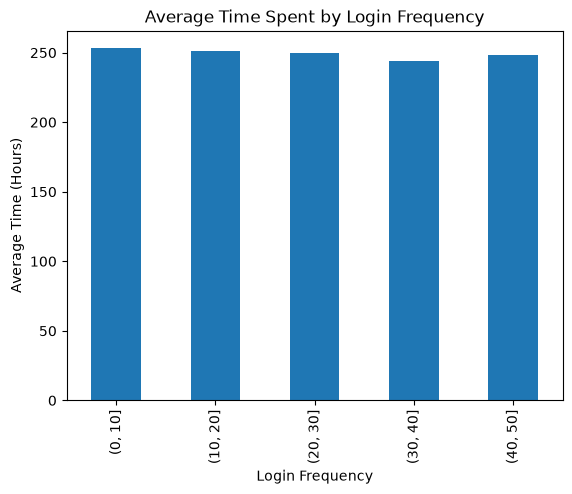

In [112]:
edtech.groupby(
    pd.cut(edtech['login_frequency'], [0,10,20,30,40,50])
)['time_spent_hours'].mean().plot(kind='bar')
plt.title('Average Time Spent by Login Frequency')
plt.xlabel('Login Frequency')
plt.ylabel('Average Time (Hours)')
plt.show()

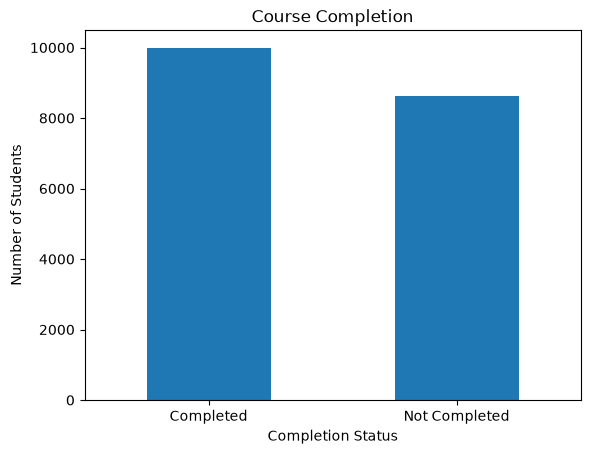

In [113]:
edtech['completion_status'].value_counts().plot(kind='bar')
plt.title('Course Completion')
plt.xlabel('Completion Status')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()

### 2. Identify patterns in course completion

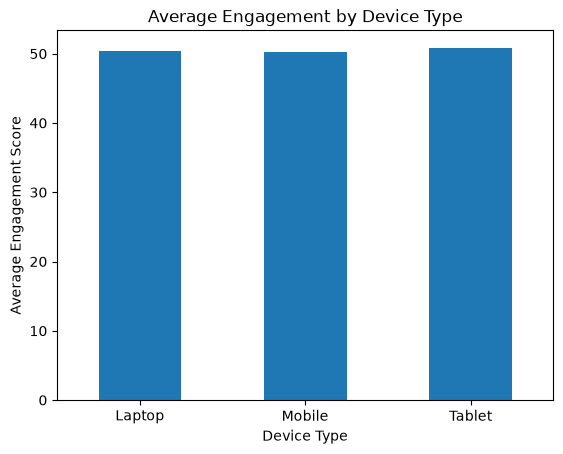

In [114]:
edtech.groupby('device_type')['engagement_score'].mean().plot(kind='bar')
plt.title('Average Engagement by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Average Engagement Score')
plt.xticks(rotation=0)
plt.show()

### 3. Compare engagement across device types and locations

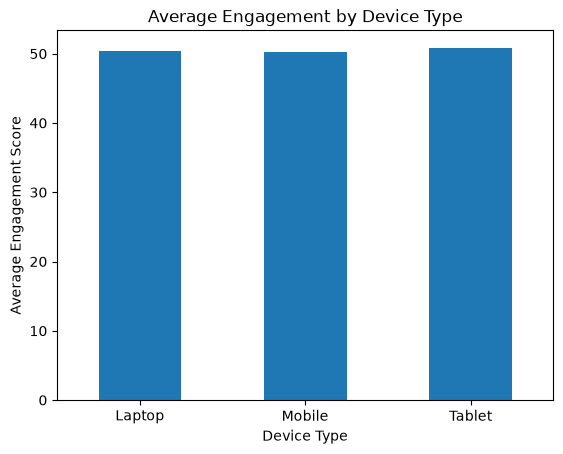

In [115]:
edtech.groupby('device_type')['engagement_score'].mean().plot(kind='bar')
plt.title('Average Engagement by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Average Engagement Score')
plt.xticks(rotation=0)
plt.show()

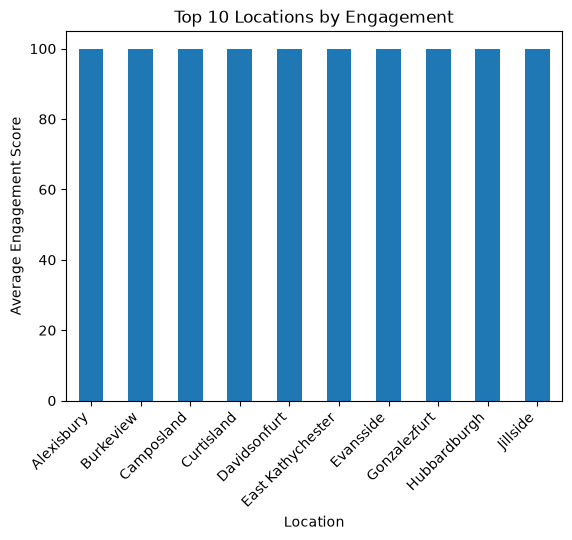

In [116]:
edtech.groupby('location')['engagement_score'].mean().nlargest(10).plot(kind='bar')
plt.title('Top 10 Locations by Engagement')
plt.xlabel('Location')
plt.ylabel('Average Engagement Score')
plt.xticks(rotation=45, ha='right')
plt.show()

### 4. Correlation between engagement score and satisfaction

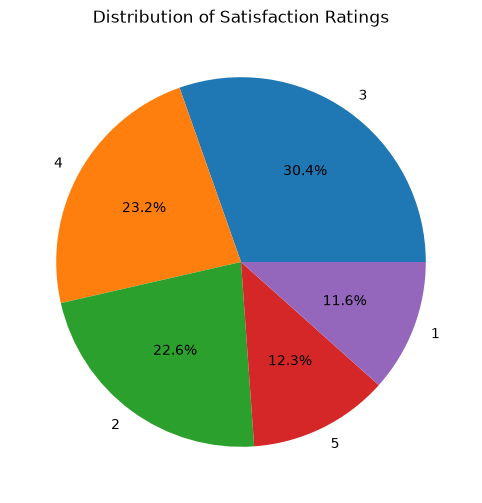

In [117]:
edtech['satisfaction_rating'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title('Distribution of Satisfaction Ratings')
plt.ylabel('')
plt.show()

### 5. Distribution of inactive users

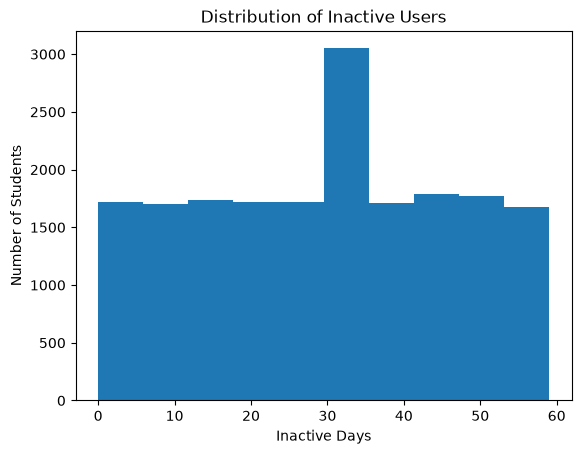

In [118]:
plt.hist(edtech['inactive_days'], bins=10)
plt.title('Distribution of Inactive Users')
plt.xlabel('Inactive Days')
plt.ylabel('Number of Students')
plt.show()

In [119]:
# MySQL credentials
username = "root"
password = "Vforvamsi@12"   # Replace with your actual MySQL password
host = "localhost"
port = 3306
database = "edtech"

# Encode password safely
encoded_password = quote_plus(password)

# Create connection
engine = create_engine(
    f"mysql+pymysql://{username}:{encoded_password}@{host}:{port}/{database}"
)

print("MySQL engine created successfully!")

MySQL engine created successfully!


In [120]:
edtech.to_sql(
    name="edtech_tab",
    con=engine,
    if_exists="replace",
    index=False
)

print("Data transferred successfully!")

Data transferred successfully!
